列名：['ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'redshift', 'class']



,u,g,r,i,z
count,1000.000000,1000.000000,1000.000000,999.000000,999.000000
mean,21.664532,19.975327,18.942794,18.403208,18.093238
std,2.167733,2.013512,1.765250,1.608441,1.596517
min,15.812780,14.929930,14.498370,14.398110,13.789400
1%,17.004191,15.502963,15.045032,14.889098,14.488132
25%,20.282463,18.693382,17.708495,17.229920,16.961315
50%,21.740055,20.147120,19.136330,18.571930,18.236830
75%,23.172837,21.258657,20.026690,19.406165,19.060025
99%,26.256128,24.692613,23.003022,22.243863,22.034438
max,27.248330,25.620750,24.802060,22.929580,23.126190


清洗后剩余数据量: 999



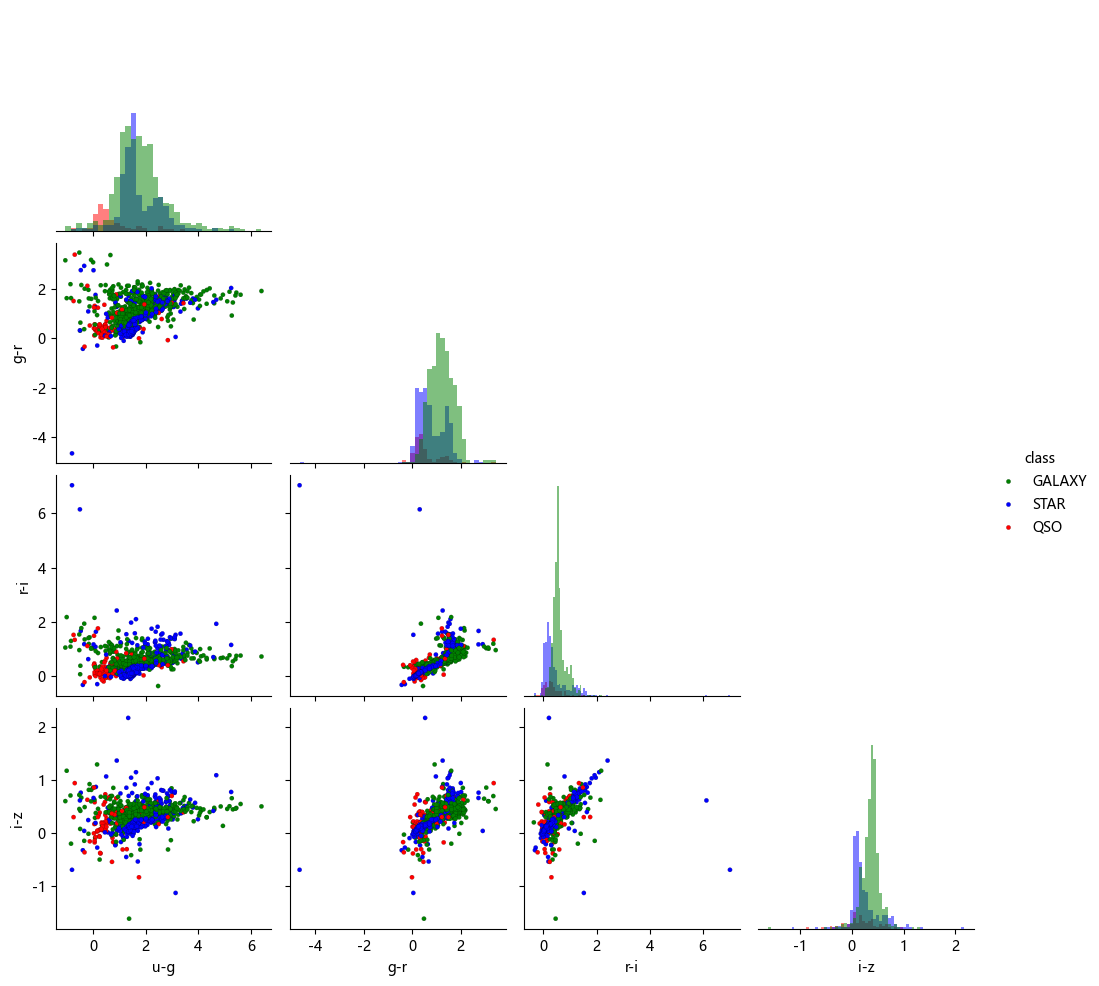


模型1准确率 (Accuracy): 0.603

分类报告:
              precision    recall  f1-score   support

      GALAXY       0.81      0.56      0.66       178
         QSO       0.30      0.70      0.42        23
        STAR       0.53      0.66      0.59        99

    accuracy                           0.60       300
   macro avg       0.55      0.64      0.56       300
weighted avg       0.68      0.60      0.62       300

模型2准确率 (Accuracy): 0.850

分类报告:
              precision    recall  f1-score   support

      GALAXY       0.97      0.77      0.86       178
         QSO       0.79      0.83      0.81        23
        STAR       0.73      1.00      0.85        99

    accuracy                           0.85       300
   macro avg       0.83      0.87      0.84       300
weighted avg       0.88      0.85      0.85       300



In [1]:
# ======================================
# 项目名称：SDSS 天文数据分类与特征分析
# 项目简介：
#   基于SDSS天文观测数据集，完成恒星、星系、类星体三类天体数据分析
#   流程包含：数据读取 → 异常值与缺失值清洗 → 构造天文颜色指数特征 → 
#            多特征可视化分布分析 → 逻辑回归两种特征方案建模对比
# 技术栈：
#   Pandas数据处理、NumPy数值计算、Matplotlib/Seaborn可视化、
#   Scikit-learn数据集划分、逻辑回归建模与模型评估
# ======================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 设置字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 读取数据（skiprows=1指跳过第一行，本 csv文件中第一行是'#Table1'）
df = pd.read_csv('sky.csv',skiprows=1)
print(f"列名：{df.columns.tolist()}")
print()

# ======================================
# 数据清洗：异常值替换 ＋ 缺失值删除
# 参数说明：
#   两层方括号代表选择多列
#   .replace：将 5 列中所有 -9999 替换为 nan
#   .describe：对 df 表格做数据统计，计算数量、均值、标准差、最小值、25%、50%、75%、最大值
#   percentiles：指定想看的分位数（数据从小到大排，第 1% 位置的数）
#   .dropna：删除含有空值的行
#   subset：指定列
# ======================================
# 异常值替换
df[['u', 'g', 'r', 'i', 'z',]] = df[['u', 'g', 'r', 'i', 'z']].replace(-9999, np.nan)
# 统计概览
display(df[['u', 'g', 'r', 'i', 'z',]].describe(percentiles=[0.01,0.25,0.5,0.75,0.99]))
# 缺失值删除
df = df.dropna(subset=['u', 'g', 'r', 'i', 'z',])
print(f"清洗后剩余数据量: {len(df)}")
print()


# ======================================
# 数据可视化：构造特征 ＋ 分类分组 ＋ 绘图
# 参数说明：
#   hue：按类别区分颜色
#   diag_kind：指定对角线子图样式
#   corner=True：只画下三角区域
#   palette：颜色
#   _kws：子图自定义属性
#   s：点大小
#   alpha：透明度
#   edgecolor：边框颜色
#   linewidth：边框长度
# ======================================
# 构造天文颜色指数特征
df['u-g'] = df['u'] - df['g']
df['g-r'] = df['g'] - df['r']
df['r-i'] = df['r'] - df['i']
df['i-z'] = df['i'] - df['z']
# 按天体类别分类样本
star = df[df['class'] == 'STAR']
galaxy = df[df['class'] == 'GALAXY']
qso = df[df['class'] == 'QSO']
# 选定数据源
data = ['u-g','g-r','r-i','i-z','class']
# 绘制矩阵图
sns.pairplot(df[data],
             hue = 'class',
             diag_kind = 'hist',
             corner=True,
             palette = {'STAR':'blue','GALAXY':'green','QSO':'red'},
             plot_kws = {'s': 10,
                         'alpha': 1,
                         'edgecolor': 'black',
                         'linewidth': 0.1
                        },
             diag_kws = {'alpha': 0.5,
                         'edgecolor': 'black',
                         'linewidth': 0
                        }
            )
plt.show()
print()


# ======================================
# 机器学习：数据集划分 ＋ 逻辑回归对比
# 简介：
#   模型 1：仅使用天文颜色指数特征
#   模型 2：加入距离（红移）特征做对比
# 参数说明：
#   train_size：训练集占比
#   random_state：随机种子
#   stratify：按标签分层划分，保证类别比例不变
#   max_iter：最大迭代次数
#   class_weight='balanced'：自动平衡各样本类别权重
# ======================================
# 准备特征
features = ['u-g', 'g-r', 'r-i', 'i-z', 'redshift']
x = df[features]
y = df['class']
# 划分测试集与训练集
x_train,x_test,y_train,y_test = train_test_split(x, 
                                                 y, 
                                                 train_size=0.7, 
                                                 random_state=26, 
                                                 stratify=y
                                                )

# 模型 1
feature1 = ['u-g', 'g-r', 'r-i', 'i-z']
# 创建逻辑回归模型并训练
model1 = LogisticRegression(max_iter=1000, class_weight='balanced')
model1.fit(x_train[feature1], y_train)
# 预测 ＋ 评估
pred1 = model1.predict(x_test[feature1])
accuracy1 = model1.score(x_test[feature1], y_test)
print(f"模型1准确率 (Accuracy): {accuracy1:.3f}")
# 详细报告
print("\n分类报告:")
print(classification_report(y_test, pred1))

# 模型 2 （将红移加入特征）
feature2 = ['u-g', 'g-r', 'r-i', 'i-z', 'redshift']
# 创建逻辑回归模型并训练
model2 = LogisticRegression(max_iter=1000, class_weight='balanced')
model2.fit(x_train[feature2], y_train)
# 预测 ＋ 评估
pred2 = model2.predict(x_test[feature2])
accuracy2 = model2.score(x_test[feature2], y_test)
print(f"模型2准确率 (Accuracy): {accuracy2:.3f}")
# 详细报告
print("\n分类报告:")
print(classification_report(y_test, pred2))